# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [8]:
import pandas as pd

df = pd.read_csv('/Users/dana/Desktop/data analytics/data/credit_risk_dataset.csv')

print(f"Розмір датасету: {df.shape}")
print(f"Розмір датасету: {df.info()}")

Розмір датасету: (32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
Ро

In [9]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [10]:
churn_dist = df['loan_status'].value_counts()
churn_percent = df['loan_status'].value_counts(normalize=True) * 100

churn_percent

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Незбалансована класифікація, оскільки класи розподілені нерівномірно: 78% проти 22%


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [11]:
# 1. Відсоток пропущених значень у кожній колонці
missing_percent = df.isnull().mean() * 100

print("Відсоток пропущених значень у колонках:")
print(missing_percent.sort_values(ascending=False))

# 2. числові та категоріальні колонки

num_cols = df.select_dtypes(include = ['int64', 'float64']).columns
cat_cols = df.select_dtypes(include = ['object']).columns

# 3. Заповнюємо пропуски

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Перевірка, чи залишилися пропуски
print("\nКількість пропущених значень після заповнення:")
print(df.isnull().sum())

Відсоток пропущених значень у колонках:
loan_int_rate                 9.563856
person_emp_length             2.747000
person_income                 0.000000
person_age                    0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

Кількість пропущених значень після заповнення:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


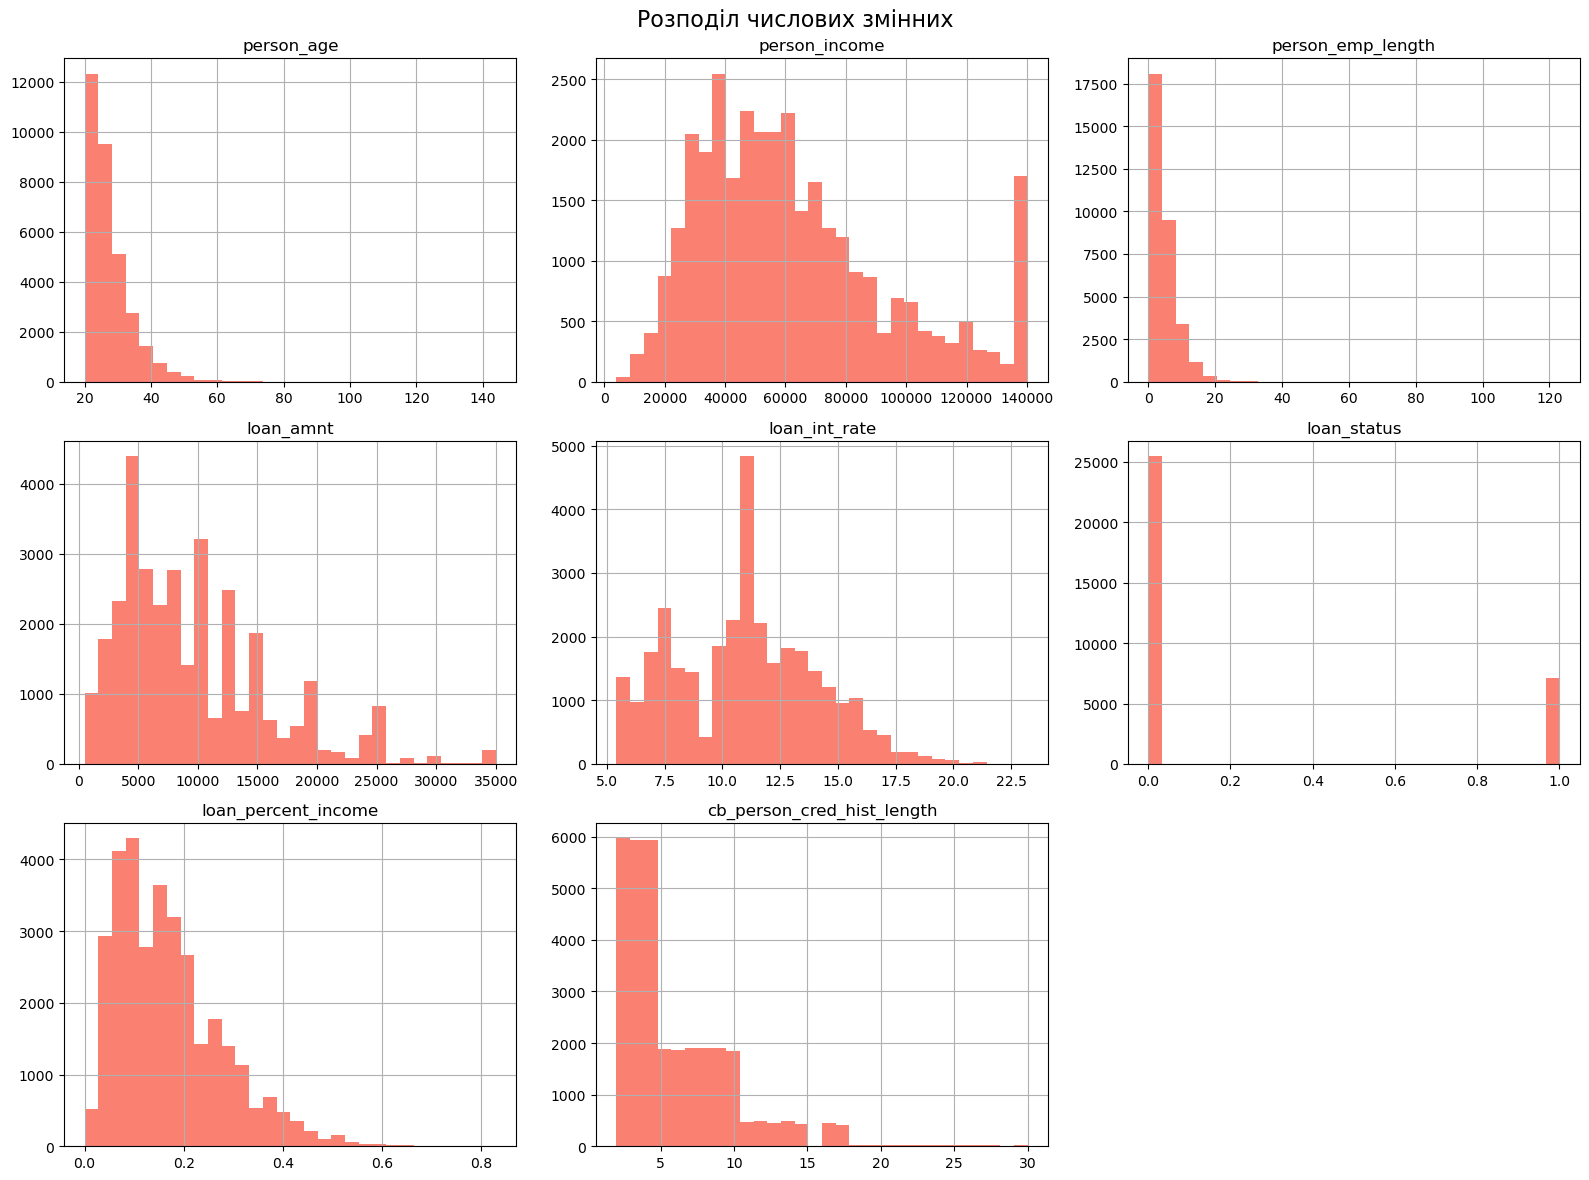

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df[num_cols].hist(figsize=(16, 12), bins=30, color='salmon')
plt.suptitle("Розподіл числових змінних", fontsize=16)
plt.tight_layout()
plt.show()

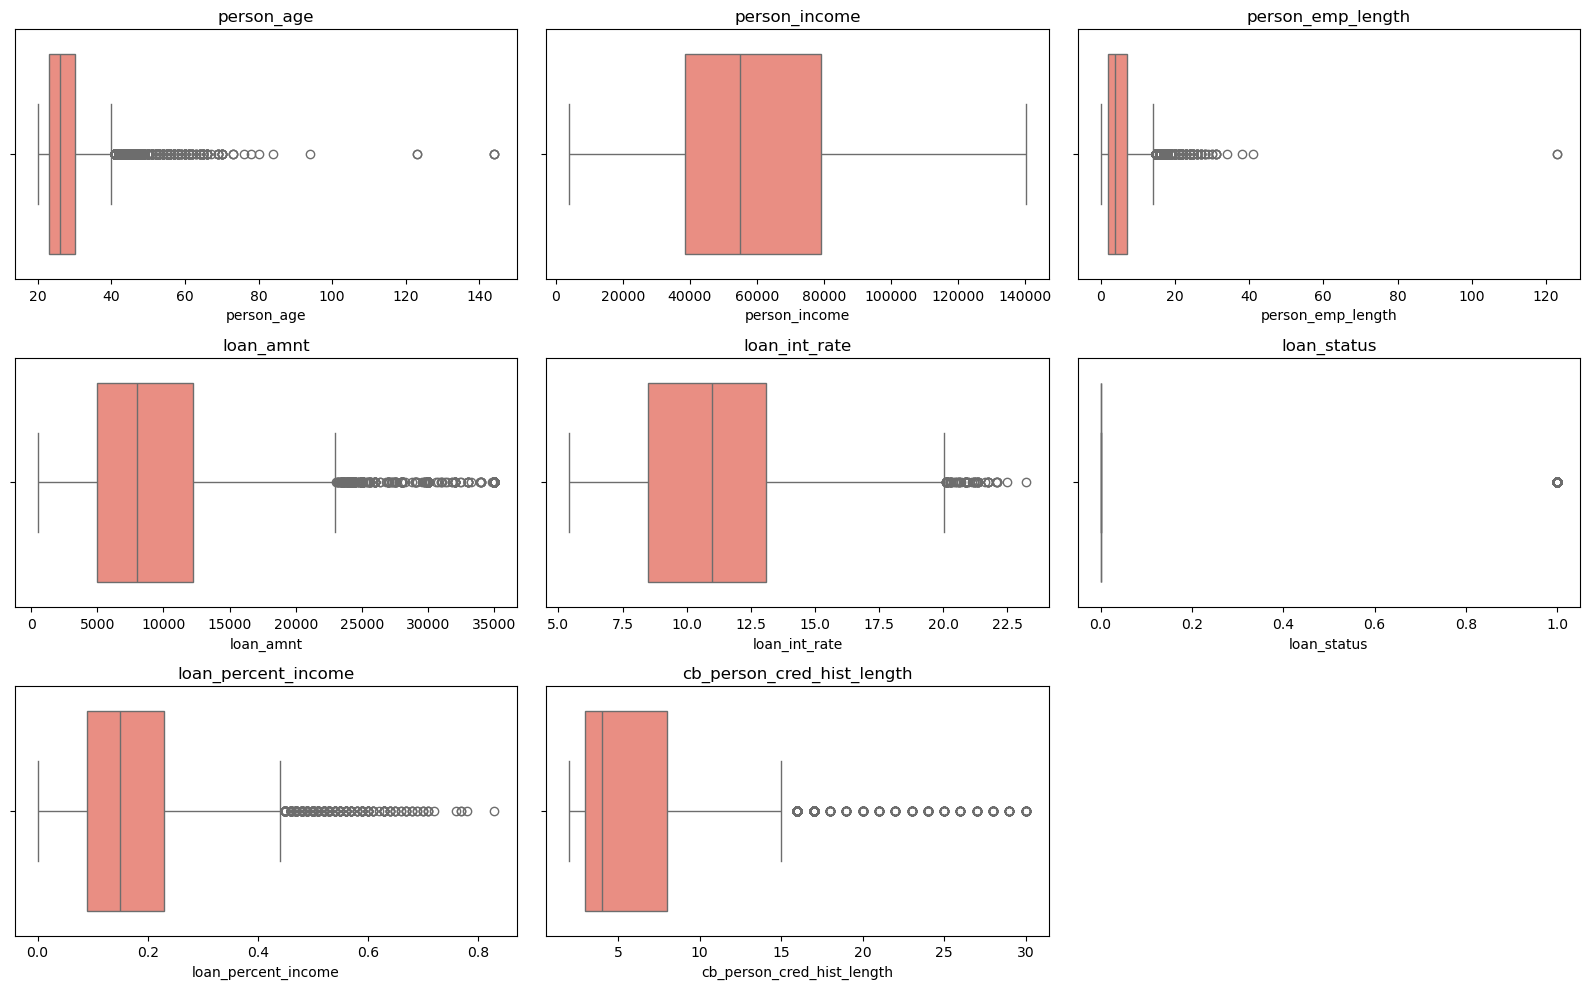

In [25]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color = 'salmon')
    plt.title(col)
    

plt.tight_layout()
plt.show()

In [14]:
#викиди в колонці person_income (Interquartile range)

Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Нижня межа:", lower_bound)
print("Верхня межа:", upper_bound)


Нижня межа: -22550.0
Верхня межа: 140250.0


In [15]:
outliers = df[(df['person_income'] < lower_bound) | 
              (df['person_income'] > upper_bound)]

print("Кількість викидів:", len(outliers))

Кількість викидів: 1484


In [16]:
df['person_income'] = df['person_income'].clip(lower_bound, upper_bound)

In [17]:
for col in cat_cols:
    summary = df.groupby(col)['loan_status'].agg(
        count='count',
        default_count='sum',
        default_rate='mean'
    )

    summary['percent_of_dataset'] = df[col].value_counts(normalize=True) * 100
    summary['default_rate'] = summary['default_rate'] * 100

    summary = summary.sort_values('default_rate', ascending=False)

    print(f'\n===== {col} =====')
    display(summary)


===== person_home_ownership =====


,count,default_count,default_rate,percent_of_dataset
person_home_ownership,,,,
RENT,16446,5192,31.569987,50.477272
OTHER,107,33,30.841121,0.328412
MORTGAGE,13444,1690,12.570663,41.263313
OWN,2584,193,7.469040,7.931003



===== loan_intent =====


,count,default_count,default_rate,percent_of_dataset
loan_intent,,,,
DEBTCONSOLIDATION,5212,1490,28.587874,15.997053
MEDICAL,6071,1621,26.700708,18.633559
HOMEIMPROVEMENT,3605,941,26.102635,11.064731
PERSONAL,5521,1098,19.887702,16.945459
EDUCATION,6453,1111,17.216798,19.806022
VENTURE,5719,847,14.810282,17.553175



===== loan_grade =====


,count,default_count,default_rate,percent_of_dataset
loan_grade,,,,
G,64,63,98.437500,0.196434
F,241,170,70.539419,0.739695
E,964,621,64.419087,2.958780
D,3626,2141,59.045780,11.129186
C,6458,1339,20.733973,19.821368
B,10451,1701,16.275954,32.076977
A,10777,1073,9.956389,33.077561



===== cb_person_default_on_file =====


,count,default_count,default_rate,percent_of_dataset
cb_person_default_on_file,,,,
Y,5745,2172,37.806789,17.632976
N,26836,4936,18.393203,82.367024


Висновки: найбільший вплив на дефолт має змінна loan_grade: зі зниженням класу кредиту частка дефолтів різко зростає (від приблизно 10% для A до майже 100% для G). Також великий вплив має кредитна історія: у клієнтів, які вже мали дефолт, ризик значно вищий (37.8% проти 18.3%).
Тип житла також впливає на ризик: клієнти, які орендують житло, мають вищу частку дефолтів (приблизно 31%), тоді як власники житла — значно нижчу (приблизно 7%). Мета кредиту має помірний вплив: найвищий ризик у кредитів на борги та медичні потреби, найнижчий — для бізнесу та освіти.

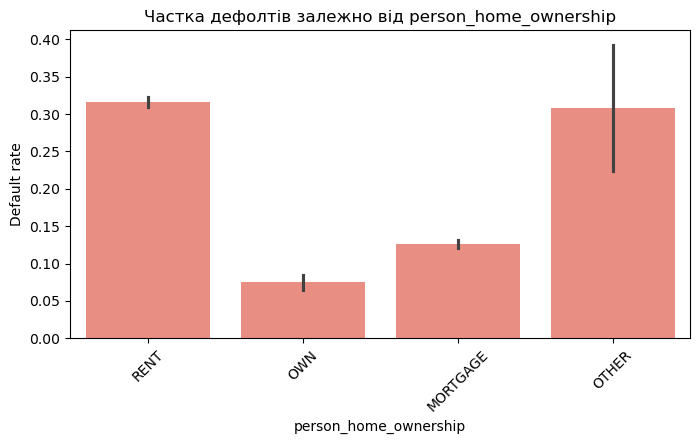

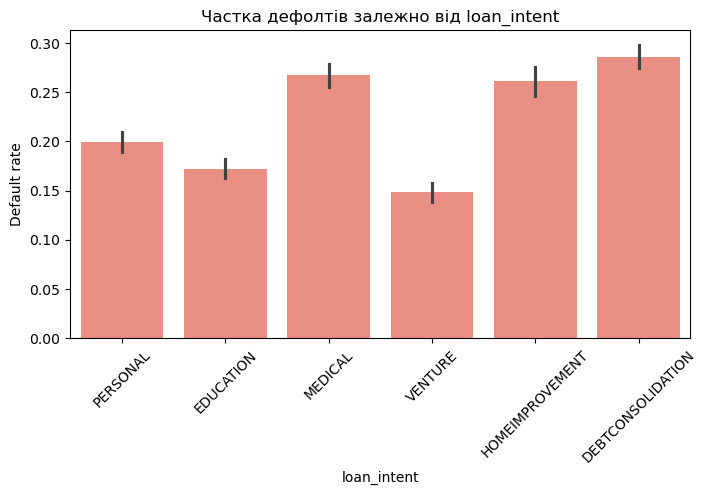

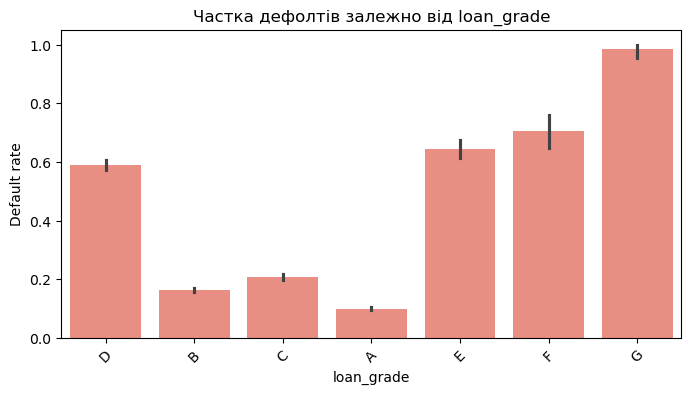

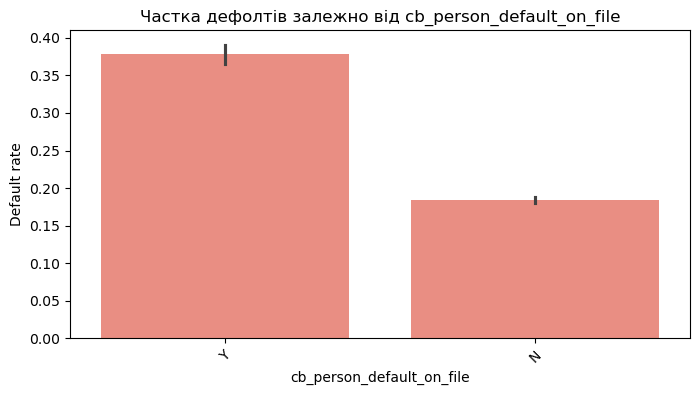

In [20]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=df,
        x=col,
        y='loan_status',
        estimator='mean',
        color='salmon'
    )
    plt.title(f'Частка дефолтів залежно від {col}')
    plt.ylabel('Default rate')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

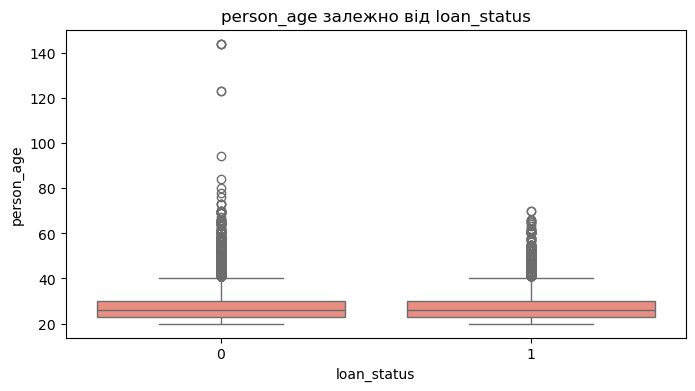

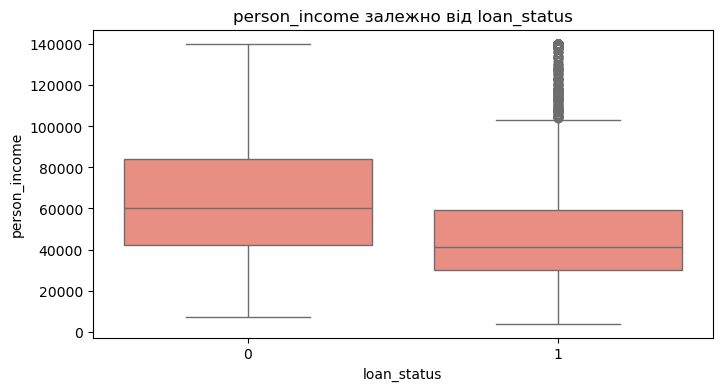

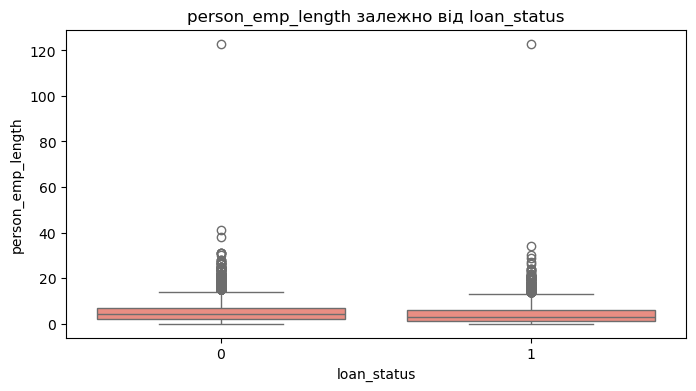

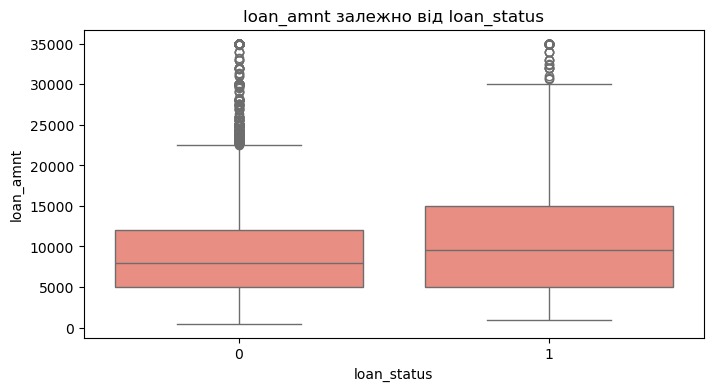

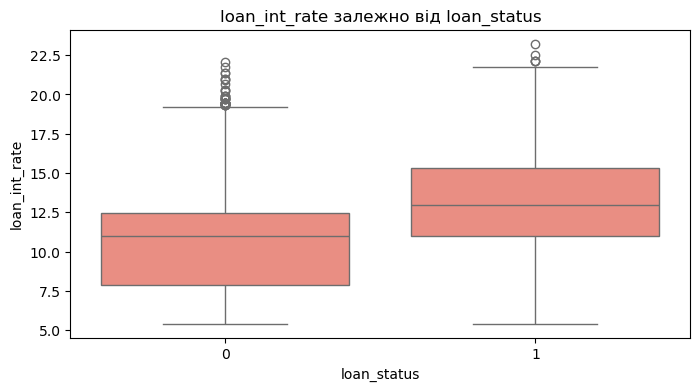

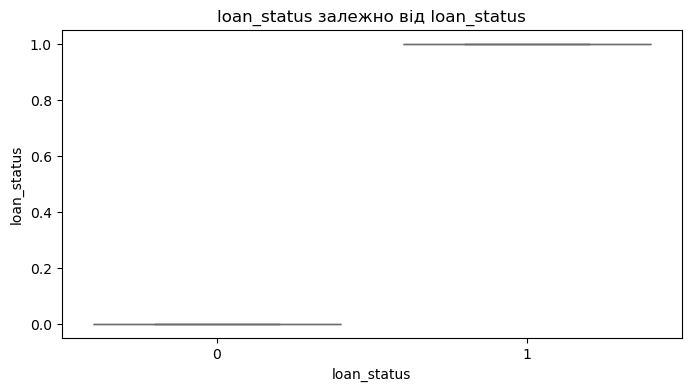

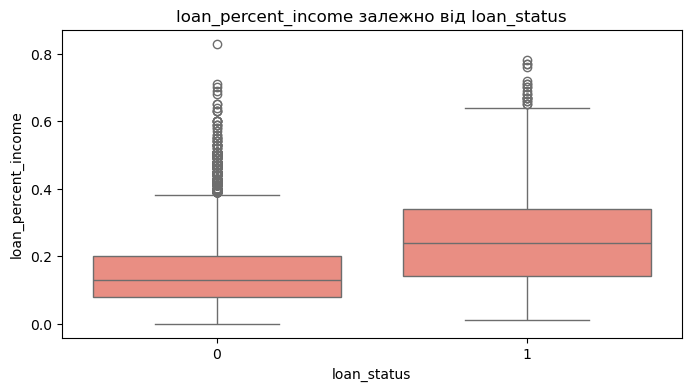

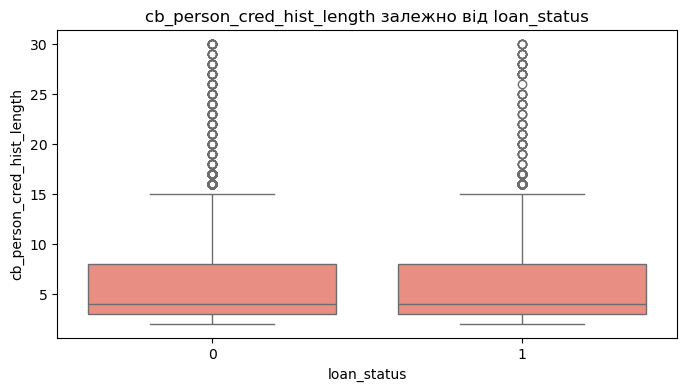

In [26]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        data=df,
        x='loan_status',
        y=col,
        color = 'salmon'
    )
    plt.title(f'{col} залежно від loan_status')
    plt.xlabel('loan_status')
    plt.ylabel(col)
    plt.show()


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [27]:
correlation_matrix = df[num_cols].corr()

correlation_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.117981,0.161454,0.050787,0.011853,-0.021629,-0.042411,0.859133
person_income,0.117981,1.000000,0.198751,0.420091,-0.017050,-0.245934,-0.367245,0.093901
person_emp_length,0.161454,0.198751,1.000000,0.113851,-0.051262,-0.082182,-0.054134,0.143069
loan_amnt,0.050787,0.420091,0.113851,1.000000,0.139483,0.105376,0.572612,0.041967
loan_int_rate,0.011853,-0.017050,-0.051262,0.139483,1.000000,0.319360,0.114514,0.015762
loan_status,-0.021629,-0.245934,-0.082182,0.105376,0.319360,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.367245,-0.054134,0.572612,0.114514,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.093901,0.143069,0.041967,0.015762,-0.015529,-0.031690,1.000000


In [31]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'person_home_ownership',
        'loan_intent',
        'loan_grade',
        'cb_person_default_on_file'
    ],
    drop_first=True,
    dtype=int
)
df_encoded.head(5)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,0,0,...,0,1,0,0,0,1,0,0,0,1
1,21,9600,5.0,1000,11.14,0,0.10,2,0,1,...,0,0,0,1,0,0,0,0,0,0
2,25,9600,1.0,5500,12.87,1,0.57,3,0,0,...,1,0,0,0,1,0,0,0,0,0
3,23,65500,4.0,35000,15.23,1,0.53,2,0,0,...,1,0,0,0,1,0,0,0,0,0
4,24,54400,8.0,35000,14.27,1,0.55,4,0,0,...,1,0,0,0,1,0,0,0,0,1



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [34]:
X = df_encoded.drop(columns='loan_status')
y = df_encoded['loan_status']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [38]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Прогнози на train:", y_train_pred[:10])
print("Прогнози на test:", y_test_pred[:10])

Прогнози на train: [0 0 0 0 0 0 0 1 0 0]
Прогнози на test: [0 0 0 0 0 0 0 0 0 1]



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


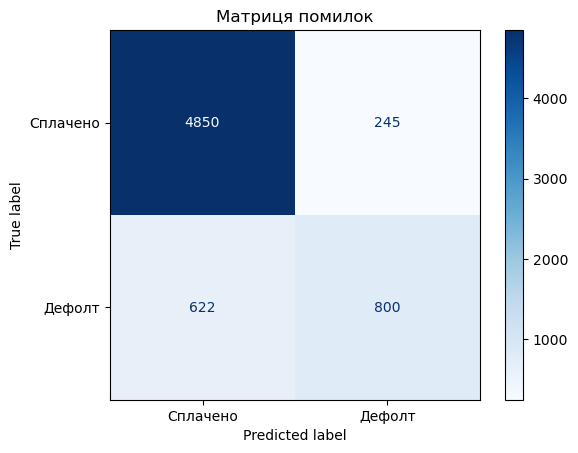

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Сплачено', 'Дефолт']
)

disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.867
Precision (Влучність):  0.766
Recall (Повнота):       0.563
F1-score:               0.649


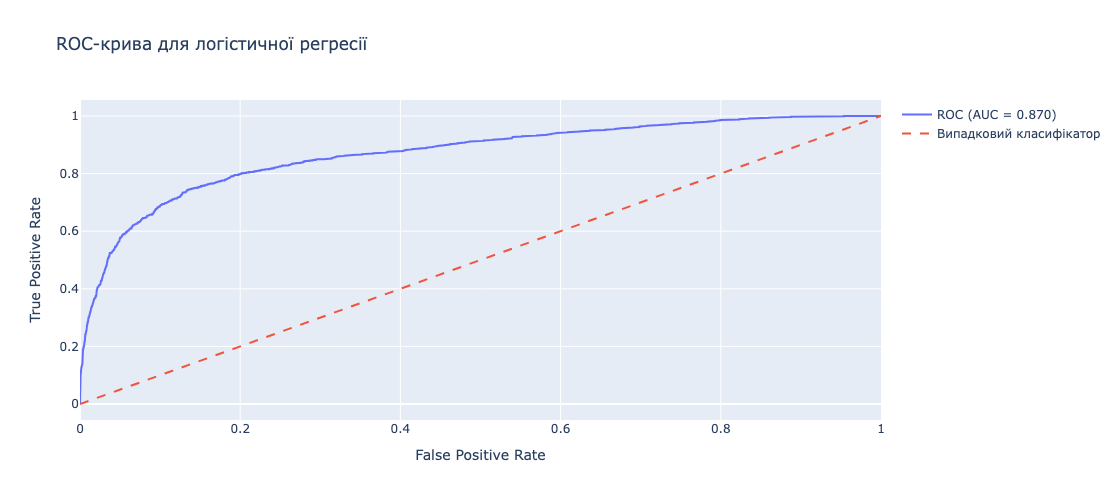

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import plotly.graph_objects as go

# Ймовірності для класу 1 = дефолт
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

# Обчислюємо ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

# Візуалізація
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC (AUC = {auc:.3f})'
))

fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    line=dict(dash='dash'),
    name='Випадковий класифікатор'
))

fig.update_layout(
    title='ROC-крива для логістичної регресії',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)

fig.show()

In [47]:
import pandas as pd
import numpy as np

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.254270,1.254270
17,loan_grade_D,0.822317,0.822317
18,loan_grade_E,0.481755,0.481755
3,loan_amnt,-0.467390,0.467390
8,person_home_ownership_OWN,-0.445162,0.445162
9,person_home_ownership_RENT,0.420598,0.420598
14,loan_intent_VENTURE,-0.411387,0.411387
10,loan_intent_EDUCATION,-0.319694,0.319694
19,loan_grade_F,0.282783,0.282783
20,loan_grade_G,0.273675,0.273675


Найбільше на прогноз дефолту впливають кредитне навантаження (loan_percent_income), кредитний рейтинг (loan_grade_D, loan_grade_E) та тип житла (person_home_ownership_RENT, person_home_ownership_OWN). Загалом модель має хорошу здатність розрізняти класи, але потребує покращення recall, оскільки пропускає значну частину реальних дефолтів.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [48]:

import plotly.express as px
from sklearn.metrics import precision_score, recall_score, f1_score

y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_test_proba >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

metrics_df

,threshold,precision,recall,f1
0,0.1,0.380836,0.877637,0.531177
1,0.3,0.621936,0.713783,0.664702
2,0.5,0.765550,0.562588,0.648561
3,0.7,0.855932,0.355134,0.501988
4,0.9,0.944724,0.132208,0.231956


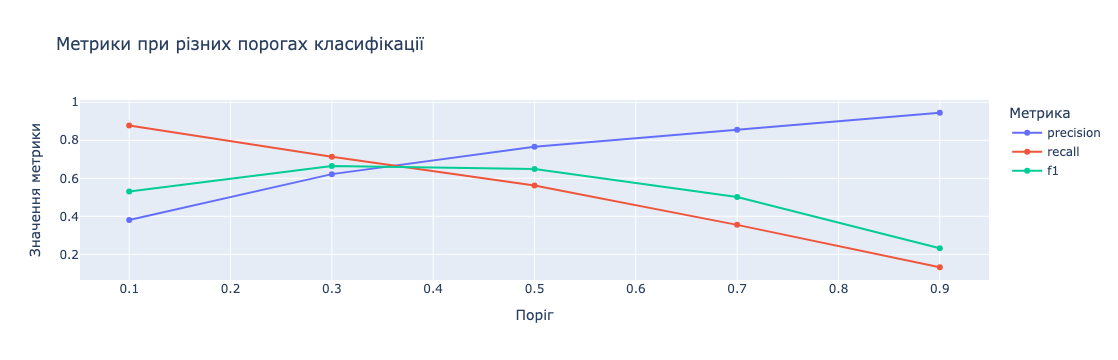

In [49]:
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    markers=True,
    title='Метрики при різних порогах класифікації',
    labels={
        'value': 'Значення метрики',
        'threshold': 'Поріг',
        'variable': 'Метрика'
    }
)

fig.show()


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Decision Tree" : DecisionTreeClassifier(random_state = 42, max_depth = 5),
    "Random Forest" : RandomForestClassifier( random_state = 42, n_estimators = 100)
}

results = []

threshold = 0.3

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
   
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)


    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

           Model  Accuracy  Precision  Recall     F1    AUC
0  Decision Tree     0.882      0.730   0.726  0.728  0.874
1  Random Forest     0.909      0.796   0.781  0.789  0.930


Я порівняла три моделі: логістичну регресію, дерево рішень і Random Forest. Найслабшою виявилась логістична регресія, вона гірше знаходить дефолти і має нижчі значення F1 та AUC. Дерево рішень показало кращий результат, але всеодно поступається Random Forest.
Найкраща модель -  Random Forest. Вона має найвищу точність. Також тут найвищий AUC, найкраще розрізняє ризикових і неризикових клієнтів.
Після зниження порогу до 0.3 моделі стали краще знаходити дефолти. Це важливо для бізнес-задачі, бо краще знайти більше ризикових клієнтів, навіть якщо буде більше помилкових спрацювань.
Висновок: для цієї задачі найкраще використовувати Random Forest з пониженим порогом класифікації.